In [2]:
%load_ext autoreload
%autoreload 2
import dev
import matplotlib.pyplot as plt
import numpy as np
import richio
import unyt as u

plt.style.use(dev.path)

In [15]:
dspace = np.logspace(2, -13) * u.g / u.cm**3
Tspace = np.logspace(3.5, 7) * u.K
T, d = np.meshgrid(Tspace, dspace, indexing="xy")

In [16]:
e = richio.eos.dT2e(d, T)
P = richio.eos.dT2p(d, T)
gamma = P / (e * d) + 1

sgas = richio.eos.dT2s(d, T)
a = 4 * u.stefan_boltzmann_constant / u.speed_of_light
s = sgas + 4 * a * T**3 / (3 * d)

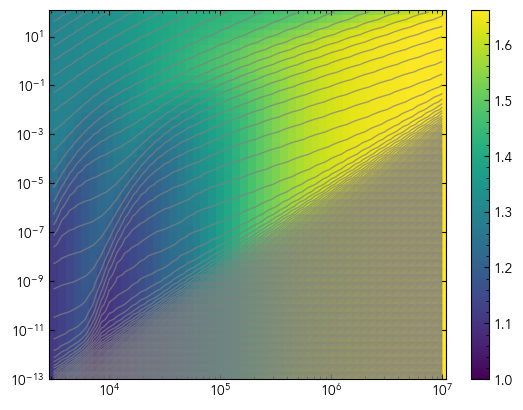

In [17]:
fig, ax = plt.subplots()
im = ax.pcolormesh(Tspace, dspace, gamma, vmin=1)
ax.contour(Tspace, dspace, np.log10(s.to_value("erg/(g*K)")), levels=300, colors="gray", alpha=0.7)
ax.set(xscale="log", yscale="log")

fig.colorbar(im, ax=ax)
plt.show()